In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, optimize
from statsmodels.tsa.stattools import adfuller
from ruptures import Pelt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [ ]:
# Загрузка данных и подготовка лог-спреда
ticker_ss = "601857.SS"
ticker_hk = "0857.HK"
start_date = "2020-01-01"
end_date = "2025-01-01"

df_ss = yf.download(ticker_ss, start=start_date, end=end_date, progress=False)
df_hk = yf.download(ticker_hk, start=start_date, end=end_date, progress=False)

common_idx = df_ss.index.intersection(df_hk.index)
df_ss = df_ss.loc[common_idx]
df_hk = df_hk.loc[common_idx]

df = pd.DataFrame({
    'SSE_Close': df_ss['Close'].squeeze(),
    'HK_Close': df_hk['Close'].squeeze()
}).dropna()

df['Log_Spread'] = np.log(df['SSE_Close']) - np.log(df['HK_Close'])
data = df['Log_Spread'].values
n = len(data)
dt = 1 / 252

Наблюдений: 1173
Среднее приращений: -0.000155, стд: 0.016113
Асимметрия: -0.2198, эксцесс: 3.8397
Jarque-Bera test: stat=729.4161, p-value=0.0000


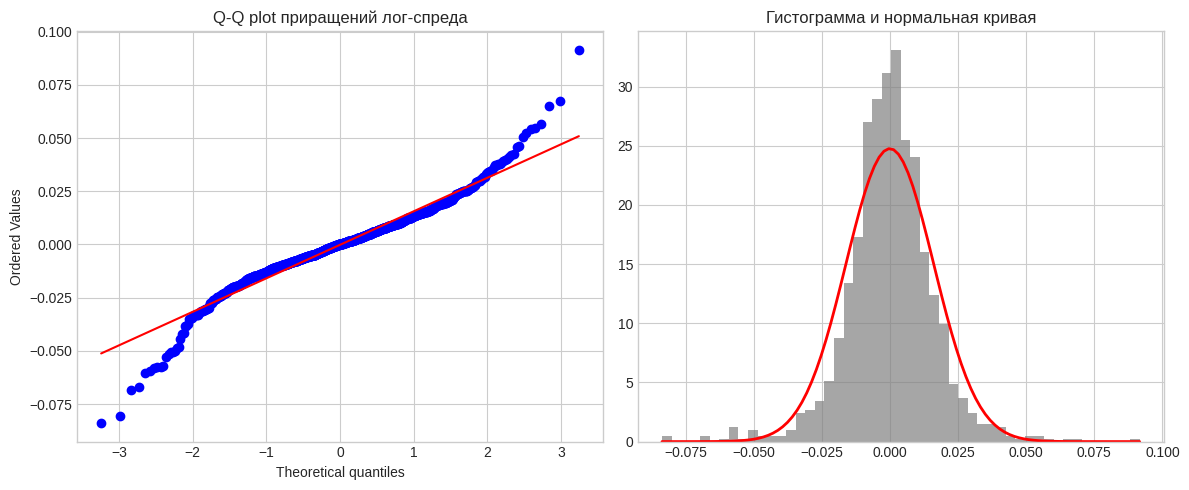

ADF test (Log_Spread): stat=-2.1032, p-value=0.2432
Найдено точек смены тенденции: 9


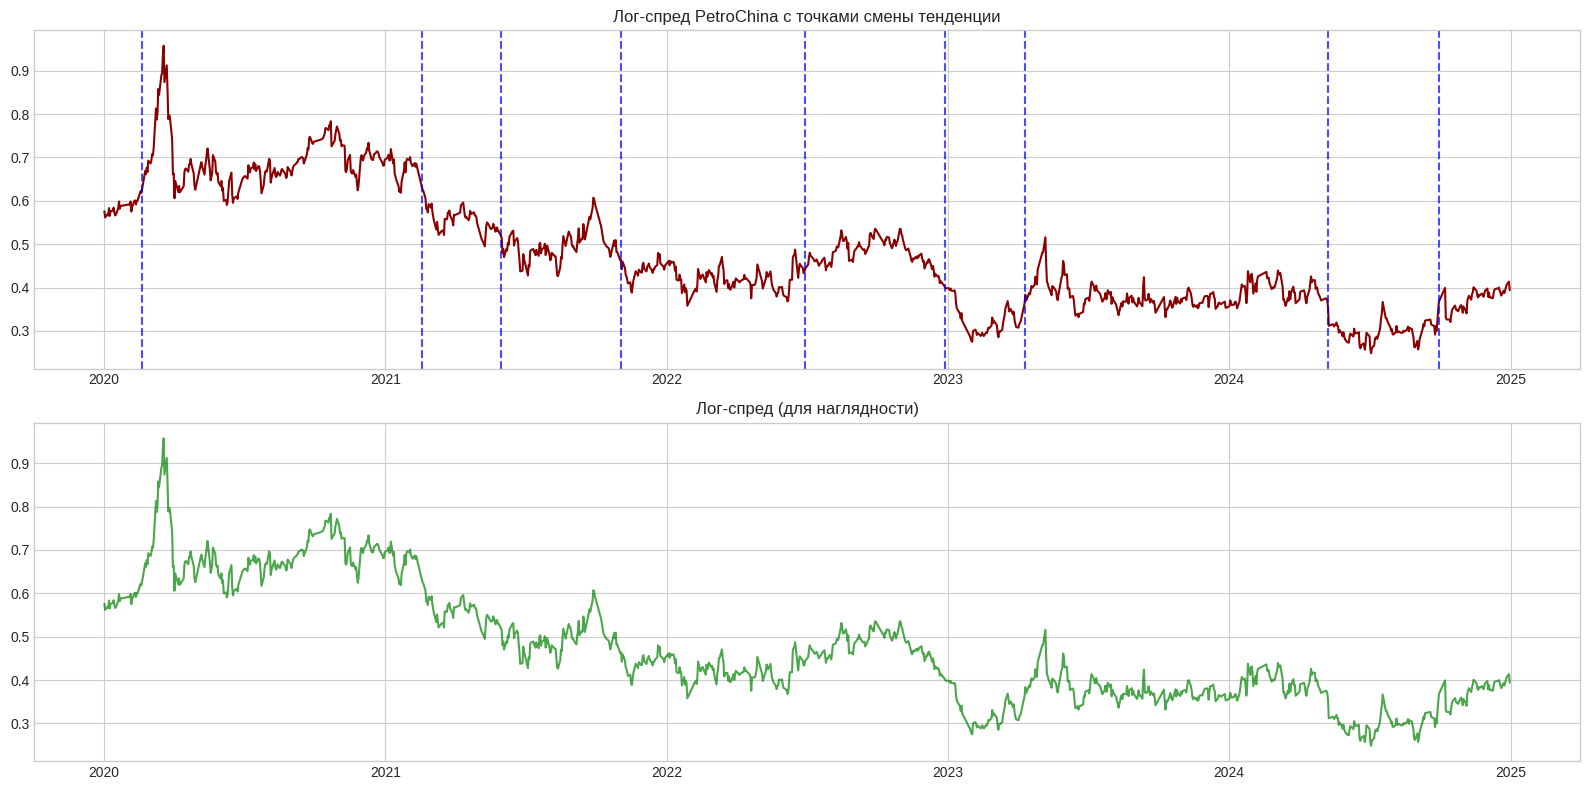

In [25]:
# Описательная статистика, проверка нормальности, ADF, точки смены тенденции
d_log_spread = np.diff(data)
print(f"Наблюдений: {n}")
print(f"Среднее приращений: {np.mean(d_log_spread):.6f}, стд: {np.std(d_log_spread):.6f}")
print(f"Асимметрия: {stats.skew(d_log_spread):.4f}, эксцесс: {stats.kurtosis(d_log_spread):.4f}")

# Проверка нормальности доходностей
jb_stat, jb_p = stats.jarque_bera(d_log_spread)
print(f"Jarque-Bera test: stat={jb_stat:.4f}, p-value={jb_p:.4f}")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
stats.probplot(d_log_spread, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q plot приращений лог-спреда')
axes[1].hist(d_log_spread, bins=50, density=True, alpha=0.7, color='gray')
x_vals = np.linspace(d_log_spread.min(), d_log_spread.max(), 100)
axes[1].plot(x_vals, stats.norm.pdf(x_vals, np.mean(d_log_spread), np.std(d_log_spread)), 'r-', lw=2)
axes[1].set_title('Гистограмма и нормальная кривая')
plt.tight_layout()
plt.show()

adf_stat, adf_p, *_ = adfuller(data)
print(f"ADF test (Log_Spread): stat={adf_stat:.4f}, p-value={adf_p:.4f}")

algo = Pelt(model="rbf").fit(data)
change_points = [df.index[i-1] for i in algo.predict(pen=10)[:-1]]
print(f"Найдено точек смены тенденции: {len(change_points)}")

# График
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
axes[0].plot(df.index, data, color='darkred')
for cp in change_points:
    axes[0].axvline(cp, color='blue', linestyle='--', alpha=0.7)
axes[0].set_title('Лог-спред PetroChina с точками смены тенденции')
axes[1].plot(df.index, data, color='green', alpha=0.7)
axes[1].set_title('Лог-спред (для наглядности)')
plt.tight_layout()
plt.show()

In [ ]:
# Функции логарифмической плотности
def loglik_euler(y, x, dt, mu, sigma):
    return stats.norm.logpdf(y, loc=x + mu(x)*dt, scale=sigma(x)*np.sqrt(dt))

def loglik_kessler(y, x, dt, mu, sigma, sigma_prime):
    sx = sigma(x)
    var = (sx**2) * dt + mu(x) * sx * sigma_prime(x) * dt**2
    var = np.maximum(var, 1e-12)
    mean = x + mu(x) * dt
    return stats.norm.logpdf(y, loc=mean, scale=np.sqrt(var))

def loglik_shoji_ozaki(y, x, dt, mu, sigma, sigma_prime):
    sx = sigma(x)
    L = mu(x) - 0.5 * sx * sigma_prime(x)
    z = (y - x) / (sx * np.sqrt(dt))
    mean_z = L * np.sqrt(dt) / sx
    return -0.5 * np.log(2*np.pi*dt) - np.log(sx) - 0.5 * (z - mean_z)**2

In [ ]:
# Функция для создания модели
def make_model(name):
    if name == 'GBM':
        def mu(x, p): return p[0] * x
        def sigma(x, p): return p[1] * x
        def sigma_prime(x, p): return p[1]
        bounds = [(1e-6, 5), (1e-6, 3)]
        guess = [0.1, 0.2]
    elif name == 'CIR':
        def mu(x, p): return p[0] * (p[1] - x)
        def sigma(x, p): return p[2] * np.sqrt(np.maximum(x, 1e-12))
        def sigma_prime(x, p): return p[2] * 0.5 / np.sqrt(np.maximum(x, 1e-12))
        bounds = [(1e-6, 10), (1e-6, 5), (1e-6, 3)]
        guess = [3.0, 0.3, 0.2]
    elif name == 'OU':
        def mu(x, p): return p[0] * (p[1] - x)
        def sigma(x, p): return p[2]
        def sigma_prime(x, p): return 0.0
        bounds = [(1e-6, 10), (1e-6, 5), (1e-6, 3)]
        guess = [3.0, 0.3, 0.2]
    elif name == 'CEV':
        def mu(x, p): return p[0] * (p[1] - x)
        def sigma(x, p): return p[2] * np.power(np.maximum(x, 1e-12), p[3])
        def sigma_prime(x, p): return p[2] * p[3] * np.power(np.maximum(x, 1e-12), p[3]-1)
        bounds = [(1e-6, 10), (1e-6, 5), (1e-6, 3), (0.1, 2.0)]
        guess = [3.0, 0.3, 0.2, 0.5]
    elif name == 'CKLS':
        def mu(x, p): return p[0] * (p[1] - x)
        def sigma(x, p): return p[2] * np.power(np.maximum(x, 1e-12), p[3])
        def sigma_prime(x, p): return p[2] * p[3] * np.power(np.maximum(x, 1e-12), p[3]-1)
        bounds = [(1e-6, 10), (1e-6, 5), (1e-6, 3), (0.1, 2.0)]
        guess = [3.0, 0.3, 0.2, 1.5]
    elif name == 'NoMeanRev':
        def mu(x, p): return p[0]
        def sigma(x, p): return p[1]
        def sigma_prime(x, p): return 0.0
        bounds = [(1e-6, 5), (1e-6, 3)]
        guess = [0.1, 0.2]
    else:
        raise ValueError(f"Unknown model: {name}")
    return mu, sigma, sigma_prime, bounds, guess

In [ ]:
# Оценка одной модели
def estimate_model(model_name, method_name, n_restarts=5):
    mu_f, sig_f, sig_p_f, bounds, init_guess = make_model(model_name)
    x = data[:-1]
    y = data[1:]

    def nll(params):
        if method_name == 'Euler':
            ll = loglik_euler(y, x, dt,
                             lambda xx: mu_f(xx, params),
                             lambda xx: sig_f(xx, params))
        elif method_name == 'Kessler':
            ll = loglik_kessler(y, x, dt,
                               lambda xx: mu_f(xx, params),
                               lambda xx: sig_f(xx, params),
                               lambda xx: sig_p_f(xx, params))
        elif method_name == 'Shoji-Ozaki':
            ll = loglik_shoji_ozaki(y, x, dt,
                                    lambda xx: mu_f(xx, params),
                                    lambda xx: sig_f(xx, params),
                                    lambda xx: sig_p_f(xx, params))
        else:
            raise ValueError(f"Unknown method: {method_name}")
        return -np.sum(ll)

    best_res = None
    best_fun = np.inf
    for _ in range(n_restarts):
        start = np.array([b[0] + np.random.rand()*(b[1]-b[0]) for b in bounds])
        res = optimize.minimize(nll, start, bounds=bounds, method='L-BFGS-B',
                                options={'maxiter': 2000})
        if res.fun < best_fun:
            best_fun = res.fun
            best_res = res
    return best_res.x, -best_res.fun, best_res

In [29]:
# Оценка всех моделей своими силами + сводная таблица параметров
model_names = ['GBM', 'CIR', 'OU', 'CEV', 'CKLS', 'NoMeanRev']
method_names = ['Euler', 'Kessler', 'Shoji-Ozaki']

results_self = []
params_dict = {}  # ключ (model, method) -> array параметров
for model_name in model_names:
    for method_name in method_names:
        try:
            params, ll, _ = estimate_model(model_name, method_name, n_restarts=5)
            aic = -2 * ll + 2 * len(params)
            bic = -2 * ll + np.log(n-1) * len(params)
            results_self.append({'Модель': model_name, 'Метод': method_name,
                                 'Log-Likelihood': ll, 'AIC': aic, 'BIC': bic})
            params_dict[(model_name, method_name)] = params
        except Exception as e:
            results_self.append({'Модель': model_name, 'Метод': method_name,
                                 'Log-Likelihood': np.nan, 'AIC': np.nan, 'BIC': np.nan})
            params_dict[(model_name, method_name)] = None

df_self = pd.DataFrame(results_self)
print("=== Результаты (собственная реализация) ===")
print(df_self.to_string(index=False))

# Сводная таблица параметров
print("\n=== Оценки параметров (собственная реализация) ===")
param_rows = []
for (model_name, method_name), p in params_dict.items():
    if p is not None:
        row = {'Модель': model_name, 'Метод': method_name}
        if model_name == 'GBM':
            row['mu (α)'] = p[0]
            row['sigma (β)'] = p[1]
        elif model_name in ['CIR', 'OU']:
            row['speed (α)'] = p[0]
            row['level (θ)'] = p[1]
            row['vol (σ)'] = p[2]
        elif model_name in ['CEV', 'CKLS']:
            row['speed (α)'] = p[0]
            row['level (θ)'] = p[1]
            row['vol (σ)'] = p[2]
            row['gamma (γ)'] = p[3]
        elif model_name == 'NoMeanRev':
            row['drift (μ)'] = p[0]
            row['sigma (σ)'] = p[1]
        param_rows.append(row)

df_params = pd.DataFrame(param_rows)
print(df_params.to_string(index=False))

=== Результаты (собственная реализация) ===
   Модель       Метод  Log-Likelihood          AIC          BIC
      GBM       Euler     3206.704634 -6409.409267 -6399.276334
      GBM     Kessler     3206.704634 -6409.409267 -6399.276334
      GBM Shoji-Ozaki     3206.704634 -6409.409267 -6399.276334
      CIR       Euler     3220.052455 -6434.104911 -6418.905510
      CIR     Kessler     3220.006697 -6434.013394 -6418.813993
      CIR Shoji-Ozaki     3220.052455 -6434.104911 -6418.905510
       OU       Euler     3177.394319 -6348.788639 -6333.589238
       OU     Kessler     3177.394319 -6348.788639 -6333.589238
       OU Shoji-Ozaki     3177.394319 -6348.788639 -6333.589238
      CEV       Euler     3222.310729 -6436.621457 -6416.355590
      CEV     Kessler     3222.329705 -6436.659411 -6416.393543
      CEV Shoji-Ozaki     3222.314417 -6436.628834 -6416.362966
     CKLS       Euler     3222.310729 -6436.621457 -6416.355590
     CKLS     Kessler     3222.329705 -6436.659411 -6416.393

In [30]:
# Оценка через pymle и сравнение
from pymle.models import CKLS as CKLS_p, CIR as CIR_p, OrnsteinUhlenbeck as OU_p, GeometricBM as GBM_p, CEV as CEV_p
from pymle.fit.AnalyticalMLE import AnalyticalMLE
from pymle.core.TransitionDensity import EulerDensity, KesslerDensity, ShojiOzakiDensity

model_map = {'GBM': GBM_p(), 'CIR': CIR_p(), 'OU': OU_p(), 'CEV': CEV_p(), 'CKLS': CKLS_p()}
bounds_pymle = {'GBM': [(1e-6,5),(1e-6,3)], 'CIR': [(1e-6,10),(1e-6,5),(1e-6,3)],
                'OU':[(1e-6,10),(1e-6,5),(1e-6,3)], 'CEV':[(1e-6,10),(1e-6,5),(1e-6,3),(0.1,2)],
                'CKLS':[(1e-6,10),(1e-6,5),(1e-6,3),(0.1,2)]}
guess_pymle = {'GBM':[0.1,0.2], 'CIR':[3,0.3,0.2], 'OU':[3,0.3,0.2], 'CEV':[3,0.3,0.2,0.5], 'CKLS':[3,0.3,0.2,1.5]}
method_map = {'Euler': EulerDensity, 'Kessler': KesslerDensity, 'Shoji-Ozaki': ShojiOzakiDensity}

results_pymle = []
for model_name in model_map:
    bnd = bounds_pymle[model_name]
    init = guess_pymle[model_name]
    for method_name, DensityClass in method_map.items():
        try:
            est = AnalyticalMLE(data, bnd, dt, density=DensityClass(model_map[model_name]))
            opt_res = est.estimate_params(init)
            results_pymle.append({'Модель': model_name, 'Метод': method_name,
                                  'Log-Likelihood': opt_res.log_like, 'AIC': opt_res.aic, 'BIC': opt_res.bic})
        except Exception as e:
            results_pymle.append({'Модель': model_name, 'Метод': method_name,
                                  'Log-Likelihood': np.nan, 'AIC': np.nan, 'BIC': np.nan})

df_pymle = pd.DataFrame(results_pymle)
print("=== Результаты (pymle) ===")
print(df_pymle.to_string(index=False))

Initial Params: [0.1, 0.2]
Initial Likelihood: 713.7635811940372
`gtol` termination condition is satisfied.
Number of iterations: 31, function evaluations: 78, CG iterations: 45, optimality: 4.03e-07, constraint violation: 0.00e+00, execution time: 0.17 s.
Final Params: [0.06672393 0.54535984]
Final Likelihood: 3206.7046337232905
Initial Params: [0.1, 0.2]
Initial Likelihood: 718.2020644956815
`xtol` termination condition is satisfied.
Number of iterations: 24, function evaluations: 42, CG iterations: 27, optimality: 1.98e+02, constraint violation: 0.00e+00, execution time: 0.076 s.
Final Params: [0.32193317 0.69273763]
Final Likelihood: 3147.7404369364604
Initial Params: [0.1, 0.2]
Initial Likelihood: 715.1610335579719
`xtol` termination condition is satisfied.
Number of iterations: 85, function evaluations: 246, CG iterations: 129, optimality: 3.70e-05, constraint violation: 0.00e+00, execution time: 0.39 s.
Final Params: [0.0668826  0.54528745]
Final Likelihood: 3206.704633491251
In

In [31]:
# Выбор лучшей модели для обеих реализаций
euler_mask = df_pymle['Метод'] == 'Euler'
best_euler_pymle = df_pymle[euler_mask].loc[df_pymle[euler_mask]['AIC'].idxmin()]
best_model_name_pymle = best_euler_pymle['Модель']
print(f"Лучшая модель pymle (Euler): {best_model_name_pymle}, AIC={best_euler_pymle['AIC']:.2f}")

model_obj_pymle = model_map[best_model_name_pymle]
DensityClass = method_map['Euler']
est = AnalyticalMLE(data, bounds_pymle[best_model_name_pymle], dt, density=DensityClass(model_obj_pymle))
opt_res = est.estimate_params(guess_pymle[best_model_name_pymle])
best_params_pymle = opt_res.params

# Лучшая модель из своей реализации
euler_self_mask = df_self['Метод'] == 'Euler'
best_euler_self = df_self[euler_self_mask].loc[df_self[euler_self_mask]['AIC'].idxmin()]
self_best_model = best_euler_self['Модель']
self_best_params = params_dict[(self_best_model, 'Euler')]
print(f"Лучшая модель self (Euler): {self_best_model}, AIC={best_euler_self['AIC']:.2f}")

Лучшая модель pymle (Euler): CEV, AIC=-6436.62
Initial Params: [3, 0.3, 0.2, 0.5]
Initial Likelihood: 2535.7696081815475
`gtol` termination condition is satisfied.
Number of iterations: 59, function evaluations: 270, CG iterations: 160, optimality: 4.31e-07, constraint violation: 0.00e+00, execution time: 0.51 s.
Final Params: [2.12022884 0.45475724 0.40824542 0.64763039]
Final Likelihood: 3222.3107287364564
Лучшая модель self (Euler): CEV, AIC=-6436.62


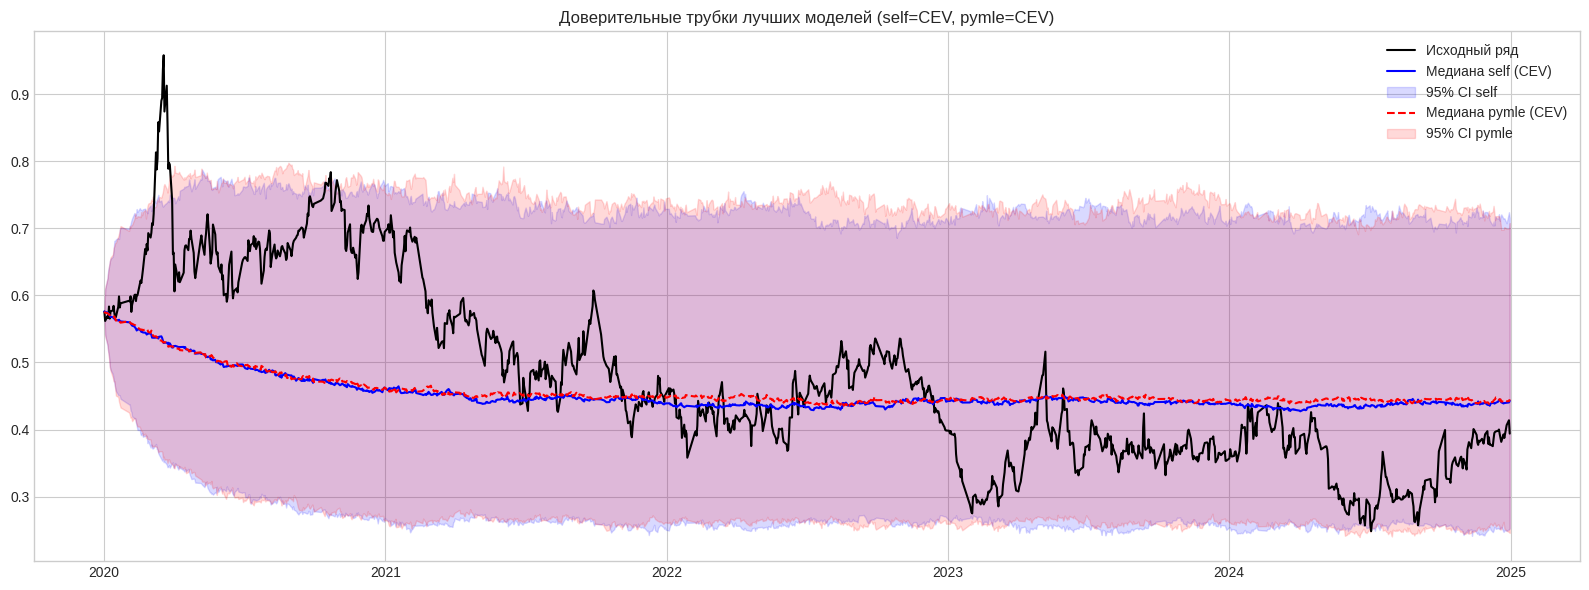

In [ ]:
# Сравнительные симуляции и доверительные трубки
from pymle.sim.Simulator1D import Simulator1D

def simulate_euler_custom(mu_func, sigma_func, params, S0, n_steps, dt, n_sim, seed=42):
    """Эйлерова симуляция для пользовательской модели."""
    np.random.seed(seed)
    paths = np.zeros((n_sim, n_steps+1))
    paths[:, 0] = S0
    for t in range(n_steps):
        x = paths[:, t]
        drift = mu_func(x, params)
        diff = sigma_func(x, params)
        paths[:, t+1] = x + drift * dt + diff * np.sqrt(dt) * np.random.randn(n_sim)
    return paths

# Получим функции mu, sigma для лучшей self-модели
mu_self, sigma_self, _, _, _ = make_model(self_best_model)

n_sim = 1000
# Симуляция self
sim_paths_self = simulate_euler_custom(mu_self, sigma_self, self_best_params,
                                        data[0], n-1, dt, n_sim, seed=42)
lower_self = np.percentile(sim_paths_self, 2.5, axis=0)
upper_self = np.percentile(sim_paths_self, 97.5, axis=0)
median_self = np.median(sim_paths_self, axis=0)

# Симуляция pymle
sim_paths_pymle = np.zeros((n_sim, n))
for i in range(n_sim):
    sim = Simulator1D(S0=data[0], M=n-1, dt=dt, model=model_obj_pymle)
    sim.set_seed(42 + i)
    sim_paths_pymle[i] = sim.sim_path().ravel()

lower_pymle = np.percentile(sim_paths_pymle, 2.5, axis=0)
upper_pymle = np.percentile(sim_paths_pymle, 97.5, axis=0)
median_pymle = np.median(sim_paths_pymle, axis=0)

# График: исходный ряд + медианы и доверительные трубки обеих моделей
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df.index, data, label='Исходный ряд', color='black', lw=1.5)
ax.plot(df.index, median_self, label=f'Медиана self ({self_best_model})', color='blue', lw=1.5)
ax.fill_between(df.index, lower_self, upper_self, color='blue', alpha=0.15, label='95% CI self')
ax.plot(df.index, median_pymle, label=f'Медиана pymle ({best_model_name_pymle})', color='red', lw=1.5, linestyle='--')
ax.fill_between(df.index, lower_pymle, upper_pymle, color='red', alpha=0.15, label='95% CI pymle')
ax.set_title(f'Доверительные трубки лучших моделей (self={self_best_model}, pymle={best_model_name_pymle})')
ax.legend()
plt.tight_layout()
plt.show()